## Exploratory Data Analysis on S&P 500 Subset

This section provides an overview and basic statistics for the subset of S&P 500 companies (top 3 by weight in each sector).

In [26]:
import pandas as pd
import numpy as np

# Load data

sectors_wgts = pd.read_csv("../data/sp500_wgts_sectors.csv")
sp500_subset = pd.read_csv("../data/sp500_subset.csv")

# Clean symbols
sectors_wgts["Symbol"] = sectors_wgts["Symbol"].astype(str).str.strip()
sp500_subset["Symbol"] = sp500_subset["Symbol"].astype(str).str.strip()

# Ensure Date is datetime
sp500_subset["Date"] = pd.to_datetime(sp500_subset["Date"])


In [27]:
# Merge weights into price data

sp500_subset = sp500_subset.merge(
    sectors_wgts[["Symbol", "Weight"]],
    on="Symbol",
    how="left",
    validate="many_to_one"   # ensures weights only appear once per symbol
)


In [28]:
sp500_subset.head()


,Date,Close,High,Low,Open,Volume,Symbol,Security,Sector,Weight
0,2020-11-23,84.081802,84.559074,83.168406,83.884313,7541500,ABBV,AbbVie,Health Care,0.007
1,2020-11-24,85.546516,86.254193,84.410945,84.657805,9322200,ABBV,AbbVie,Health Care,0.007
2,2020-11-25,85.744026,85.957977,85.077496,85.431334,6368100,ABBV,AbbVie,Health Care,0.007
3,2020-11-27,86.311798,87.060621,85.826302,86.385860,4418800,ABBV,AbbVie,Health Care,0.007
4,2020-11-30,86.056725,86.747940,85.291446,86.501080,20726500,ABBV,AbbVie,Health Care,0.007


In [29]:
sectors_wgts.head()

,Symbol,Security,Sector,Weight
0,MMM,3M,Industrials,0.0015
1,AOS,A. O. Smith,Industrials,0.0002
2,ABT,Abbott Laboratories,Health Care,0.0037
3,ABBV,AbbVie,Health Care,0.0070
4,ACN,Accenture,Information Technology,0.0026


In [30]:
# Quick checks

# S&P 500 Subset (Price Data)

print("Price data shape:", sp500_subset.shape)
print("\nColumns in price data:", sp500_subset.columns)
print("\nDate range:")
print("Min:", sp500_subset["Date"].min(), "| Max:", sp500_subset["Date"].max())
print("\nNumber of symbols in price subset:", sp500_subset["Symbol"].nunique())
print("\nMissing values:")
print(sp500_subset.isna().sum())

Price data shape: (41125, 10)

Columns in price data: Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Symbol', 'Security',
       'Sector', 'Weight'],
      dtype='object')

Date range:
Min: 2020-11-23 00:00:00 | Max: 2025-11-20 00:00:00

Number of symbols in price subset: 33

Missing values:
Date        0
Close       0
High        0
Low         0
Open        0
Volume      0
Symbol      0
Security    0
Sector      0
Weight      0
dtype: int64


In [31]:
# Weights and Sectors Data

print("Weight data shape:", sectors_wgts.shape)
print("\nColumns in weight data:", sectors_wgts.columns)
print("Number of sectors in weight dataset:", sectors_wgts["Sector"].nunique())
print("\nMissing values:")
print(sectors_wgts.isna().sum())

Weight data shape: (503, 4)

Columns in weight data: Index(['Symbol', 'Security', 'Sector', 'Weight'], dtype='object')
Number of sectors in weight dataset: 11

Missing values:
Symbol      0
Security    0
Sector      0
Weight      0
dtype: int64


In [32]:
print(sp500_subset.head())
print(sp500_subset.isna().sum())

missing = sp500_subset[sp500_subset["Weight"].isna()]["Symbol"].unique()
print("Symbols missing weights:", missing)

        Date      Close       High        Low       Open    Volume Symbol  \
0 2020-11-23  84.081802  84.559074  83.168406  83.884313   7541500   ABBV   
1 2020-11-24  85.546516  86.254193  84.410945  84.657805   9322200   ABBV   
2 2020-11-25  85.744026  85.957977  85.077496  85.431334   6368100   ABBV   
3 2020-11-27  86.311798  87.060621  85.826302  86.385860   4418800   ABBV   
4 2020-11-30  86.056725  86.747940  85.291446  86.501080  20726500   ABBV   

  Security       Sector  Weight  
0   AbbVie  Health Care   0.007  
1   AbbVie  Health Care   0.007  
2   AbbVie  Health Care   0.007  
3   AbbVie  Health Care   0.007  
4   AbbVie  Health Care   0.007  
Date        0
Close       0
High        0
Low         0
Open        0
Volume      0
Symbol      0
Security    0
Sector      0
Weight      0
dtype: int64
Symbols missing weights: []


In [33]:
# Total sum of weights from S&P 500 subset

unique_securities = (
    sp500_subset[["Symbol", "Security", "Sector", "Weight"]]
    .drop_duplicates("Symbol")
    .sort_values("Weight", ascending=False)
)

sum_weights = unique_securities["Weight"].sum()
print(f"Total sum of weights in subset: {sum_weights*100:.2f}%")

Total sum of weights in subset: 49.96%


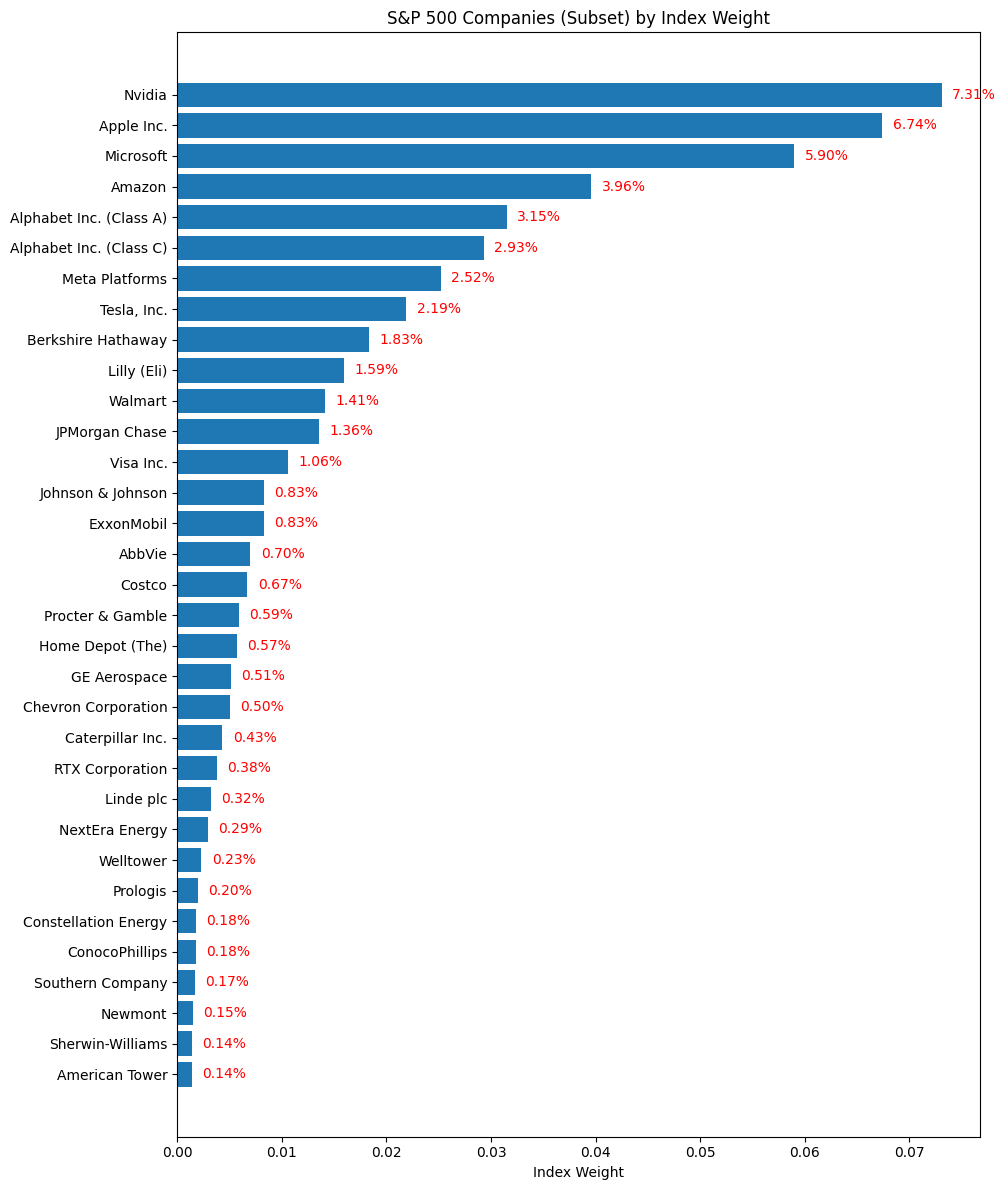

In [34]:
# Plot all S&P 500 Subset companies by weight with % labels

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 12))
bars = plt.barh(
    unique_securities["Security"],
    unique_securities["Weight"]
)
plt.gca().invert_yaxis()
plt.title("S&P 500 Companies (Subset) by Index Weight")
plt.xlabel("Index Weight")
plt.tight_layout()

# Add % labels in red at the end of each bar
for bar, weight in zip(bars, unique_securities["Weight"]):
    plt.text(
        bar.get_width() + 0.001,  # Slightly after the end of the bar
        bar.get_y() + bar.get_height() / 2,
        f"{weight*100:.2f}%",
        va='center',
        ha='left',
        color='red',
        fontsize=10
    )

plt.show()


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# Number of sectors to randomly include
X = 5   # <-- change this number to pick 5 sectors, or 3, or 8, etc.

# Get unique sectors
all_sectors = sorted(sp500_subset["Sector"].unique())

# Randomly pick X sectors
chosen_sectors = np.random.choice(all_sectors, size=X, replace=False)
print("Randomly selected sectors:", chosen_sectors)

# Filter to only those sectors
filtered = sp500_subset[sp500_subset["Sector"].isin(chosen_sectors)]

# Pick 1 random company for each chosen sector
unique_sec = filtered[["Symbol", "Sector"]].drop_duplicates()

selected_symbols = (
    unique_sec
    .groupby("Sector")["Symbol"]
    .apply(lambda x: np.random.choice(list(x), 1)[0])
)

print("\nRandomly selected companies from these sectors:")
print(selected_symbols)


Randomly selected sectors: ['Health Care' 'Communication Services' 'Real Estate' 'Utilities'
 'Consumer Staples']

Randomly selected companies from these sectors:
Sector
Communication Services    GOOGL
Consumer Staples            WMT
Health Care                 JNJ
Real Estate                 AMT
Utilities                   NEE
Name: Symbol, dtype: object


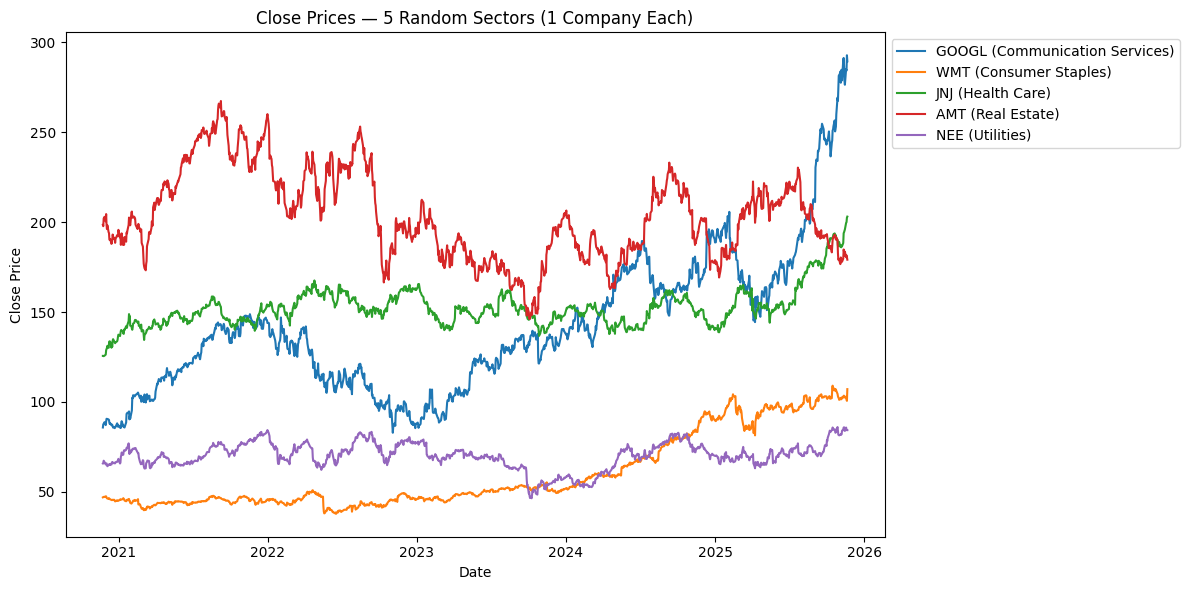

In [36]:
# Plot Close prices 

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for sym in selected_symbols:
    sub = filtered[filtered["Symbol"] == sym]
    plt.plot(sub["Date"], sub["Close"], label=f"{sym} ({sub['Sector'].iloc[0]})")

plt.title(f"Close Prices — {X} Random Sectors (1 Company Each)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()



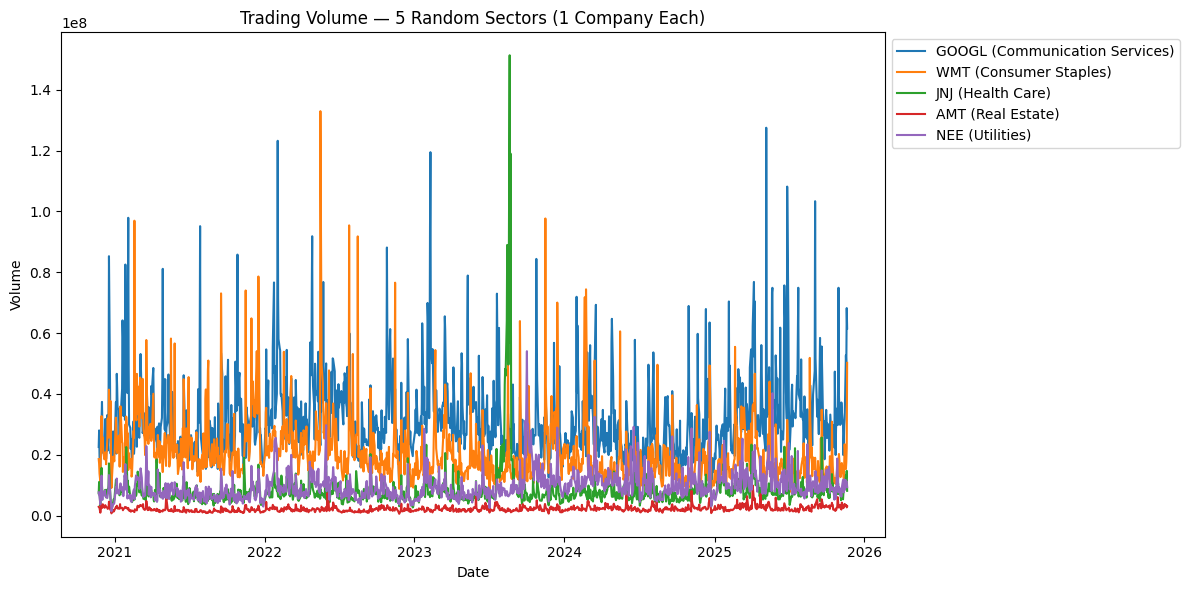

In [37]:
# Plot Volume

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for sym in selected_symbols:
    sub = filtered[filtered["Symbol"] == sym]
    plt.plot(sub["Date"], sub["Volume"], label=f"{sym} ({sub['Sector'].iloc[0]})")

plt.title(f"Trading Volume — {X} Random Sectors (1 Company Each)")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()



In [38]:
# Calculate daily returns and log returns
import numpy as np

sp500_subset2 = sp500_subset.sort_values(["Symbol", "Date"]).copy()

sp500_subset2["Return"] = (
    sp500_subset2.groupby("Symbol")["Close"]
    .transform(lambda x: x.pct_change())
)

sp500_subset2["LogReturn"] = np.log1p(sp500_subset2["Return"])

sp500_subset2

,Date,Close,High,Low,Open,Volume,Symbol,Security,Sector,Weight,Return,LogReturn
6275,2020-11-23,110.827545,114.497465,110.730201,114.069143,127959300,AAPL,Apple Inc.,Information Technology,0.0674,NaN,NaN
6276,2020-11-24,112.112503,112.774451,109.600994,110.885958,113874200,AAPL,Apple Inc.,Information Technology,0.0674,0.011594,0.011528
6277,2020-11-25,112.949669,113.650556,112.112499,112.482416,76499200,AAPL,Apple Inc.,Information Technology,0.0674,0.007467,0.007439
6278,2020-11-27,113.494804,114.370913,113.134632,113.475339,46691300,AAPL,Apple Inc.,Information Technology,0.0674,0.004826,0.004815
6279,2020-11-30,115.889488,117.758515,113.708950,113.864706,169410200,AAPL,Apple Inc.,Information Technology,0.0674,0.021100,0.020880
...,...,...,...,...,...,...,...,...,...,...,...,...
16020,2025-11-14,119.290001,119.480003,116.660004,118.449997,17064300,XOM,ExxonMobil,Energy,0.0083,0.012993,0.012909
16021,2025-11-17,117.680000,119.500000,117.110001,118.970001,16034900,XOM,ExxonMobil,Energy,0.0083,-0.013497,-0.013588
16022,2025-11-18,119.029999,119.480003,116.480003,117.260002,15808500,XOM,ExxonMobil,Energy,0.0083,0.011472,0.011406
16023,2025-11-19,117.349998,118.180000,115.930000,116.849998,15919200,XOM,ExxonMobil,Energy,0.0083,-0.014114,-0.014215


In [39]:
sp500_subset2

,Date,Close,High,Low,Open,Volume,Symbol,Security,Sector,Weight,Return,LogReturn
6275,2020-11-23,110.827545,114.497465,110.730201,114.069143,127959300,AAPL,Apple Inc.,Information Technology,0.0674,NaN,NaN
6276,2020-11-24,112.112503,112.774451,109.600994,110.885958,113874200,AAPL,Apple Inc.,Information Technology,0.0674,0.011594,0.011528
6277,2020-11-25,112.949669,113.650556,112.112499,112.482416,76499200,AAPL,Apple Inc.,Information Technology,0.0674,0.007467,0.007439
6278,2020-11-27,113.494804,114.370913,113.134632,113.475339,46691300,AAPL,Apple Inc.,Information Technology,0.0674,0.004826,0.004815
6279,2020-11-30,115.889488,117.758515,113.708950,113.864706,169410200,AAPL,Apple Inc.,Information Technology,0.0674,0.021100,0.020880
...,...,...,...,...,...,...,...,...,...,...,...,...
16020,2025-11-14,119.290001,119.480003,116.660004,118.449997,17064300,XOM,ExxonMobil,Energy,0.0083,0.012993,0.012909
16021,2025-11-17,117.680000,119.500000,117.110001,118.970001,16034900,XOM,ExxonMobil,Energy,0.0083,-0.013497,-0.013588
16022,2025-11-18,119.029999,119.480003,116.480003,117.260002,15808500,XOM,ExxonMobil,Energy,0.0083,0.011472,0.011406
16023,2025-11-19,117.349998,118.180000,115.930000,116.849998,15919200,XOM,ExxonMobil,Energy,0.0083,-0.014114,-0.014215


In [40]:
# Weighted Summary Statistics

import numpy as np
import pandas as pd

# Assign Year + Weights
sp500_subset2["Year"] = sp500_subset2["Date"].dt.year
year_weights = {2020:0.10, 2021:0.10, 2022:0.10, 2023:0.20, 2024:0.30, 2025:0.30}
sp500_subset2["YearWeight"] = sp500_subset2["Year"].map(year_weights)

# ---- Weighted Functions ----

def weighted_mean(values, weights):
    mask = values.notna()
    v = values[mask]
    w = weights[mask]
    return np.average(v, weights=w)

def weighted_sd(values, weights):
    mask = values.notna()
    v = values[mask]
    w = weights[mask]
    mean_w = np.average(v, weights=w)
    var_w = np.average((v - mean_w)**2, weights=w)
    return np.sqrt(var_w)

# ---- Grouped weighted calculations ----

weighted_summary2 = sp500_subset2.groupby("Symbol").apply(
    lambda g: pd.Series({
        "W_Daily_Return": weighted_mean(g["Return"], g["YearWeight"]),
        "W_Daily_LogReturn": weighted_mean(g["LogReturn"], g["YearWeight"]),
        "W_SD_Return": weighted_sd(g["Return"], g["YearWeight"]),
        "W_SD_LogReturn": weighted_sd(g["LogReturn"], g["YearWeight"])
    })
).reset_index()

# ---- Annualizations ----

weighted_summary2["W_Annual_LogReturn"] = weighted_summary2["W_Daily_LogReturn"] * 252
weighted_summary2["W_Annual_Return"] = np.exp(weighted_summary2["W_Annual_LogReturn"]) - 1

weighted_summary2["W_Annual_SD"] = weighted_summary2["W_SD_Return"] * np.sqrt(252)
weighted_summary2["W_Annual_LogSD"] = weighted_summary2["W_SD_LogReturn"] * np.sqrt(252)

# ---- Final Clean Order ----

weighted_summary2 = weighted_summary2[[
    "Symbol",
    "W_Daily_Return",
    "W_Daily_LogReturn",
    "W_Annual_Return",
    "W_Annual_LogReturn",
    "W_SD_Return",
    "W_SD_LogReturn",
    "W_Annual_SD",
    "W_Annual_LogSD"
]]

weighted_summary2

/var/folders/sx/rlv33lyd2zs6vjp3khdjp3dc0000gn/T/ipykernel_71211/1467495533.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_summary2 = sp500_subset2.groupby("Symbol").apply(


,Symbol,W_Daily_Return,W_Daily_LogReturn,W_Annual_Return,W_Annual_LogReturn,W_SD_Return,W_SD_LogReturn,W_Annual_SD,W_Annual_LogSD
0,AAPL,0.000942,0.000792,0.220755,0.199470,0.017378,0.017290,0.275861,0.274473
1,ABBV,0.000894,0.000785,0.218818,0.197882,0.014606,0.014743,0.231869,0.234040
2,AMT,0.000005,-0.000125,-0.031072,-0.031565,0.016158,0.016157,0.256498,0.256488
3,AMZN,0.000895,0.000670,0.183960,0.168865,0.021234,0.021204,0.337073,0.336601
4,BRK-B,0.000710,0.000654,0.179136,0.164782,0.010579,0.010582,0.167929,0.167986
5,CAT,0.001290,0.001122,0.326867,0.282821,0.018331,0.018249,0.291000,0.289694
6,CEG,0.002671,0.002150,0.719080,0.541789,0.032447,0.032107,0.515087,0.509690
7,COP,0.000390,0.000193,0.049879,0.048675,0.019795,0.019854,0.314232,0.315179
8,COST,0.000889,0.000798,0.222629,0.201004,0.013450,0.013499,0.213516,0.214289
9,CVX,0.000424,0.000309,0.080926,0.077818,0.015167,0.015229,0.240772,0.241753


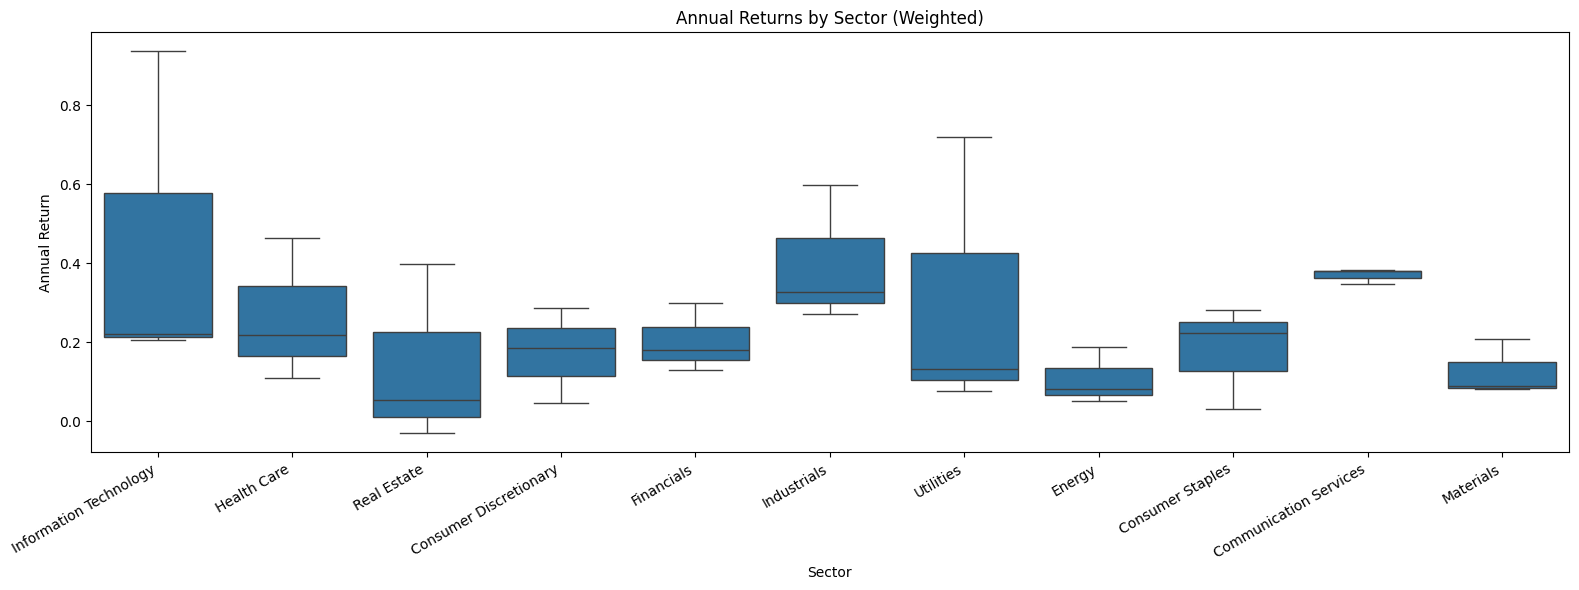

In [41]:
# Boxplot of annual log return by sector

import seaborn as sns
import matplotlib.pyplot as plt

# Attach Sector to weighted summary for boxplot
returns_df = weighted_summary2.merge(
    sp500_subset2[["Symbol", "Sector"]].drop_duplicates(),
    on="Symbol",
    how="left"
)

plt.figure(figsize=(16, 6))
sns.boxplot(data=returns_df, x="Sector", y="W_Annual_Return")
plt.xticks(rotation=30, ha='right')
plt.title("Annual Returns by Sector (Weighted)")
plt.xlabel("Sector")
plt.ylabel("Annual Return")
plt.tight_layout()
plt.show()

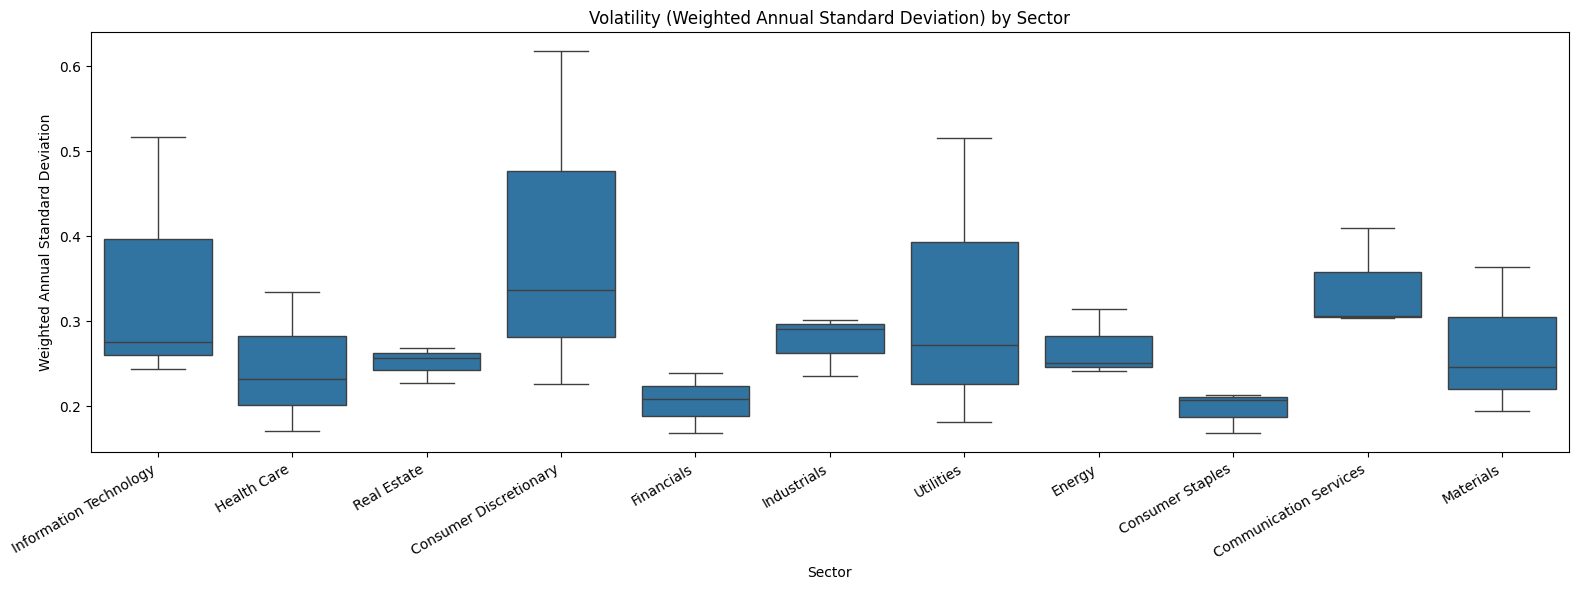

In [42]:
# Boxplot of volatility (SD of returns) by sector

import matplotlib.pyplot as plt
import seaborn as sns

# Make sure Sector column exists in weighted_summary
vol_df = weighted_summary2.merge(
    sp500_subset2[["Symbol", "Sector"]].drop_duplicates(),
    on="Symbol",
    how="left"
)

plt.figure(figsize=(16, 6))
sns.boxplot(data=vol_df, x="Sector", y="W_Annual_SD")
plt.xticks(rotation=30, ha='right')
plt.title("Volatility (Weighted Annual Standard Deviation) by Sector")
plt.xlabel("Sector")
plt.ylabel("Weighted Annual Standard Deviation")
plt.tight_layout()
plt.show()


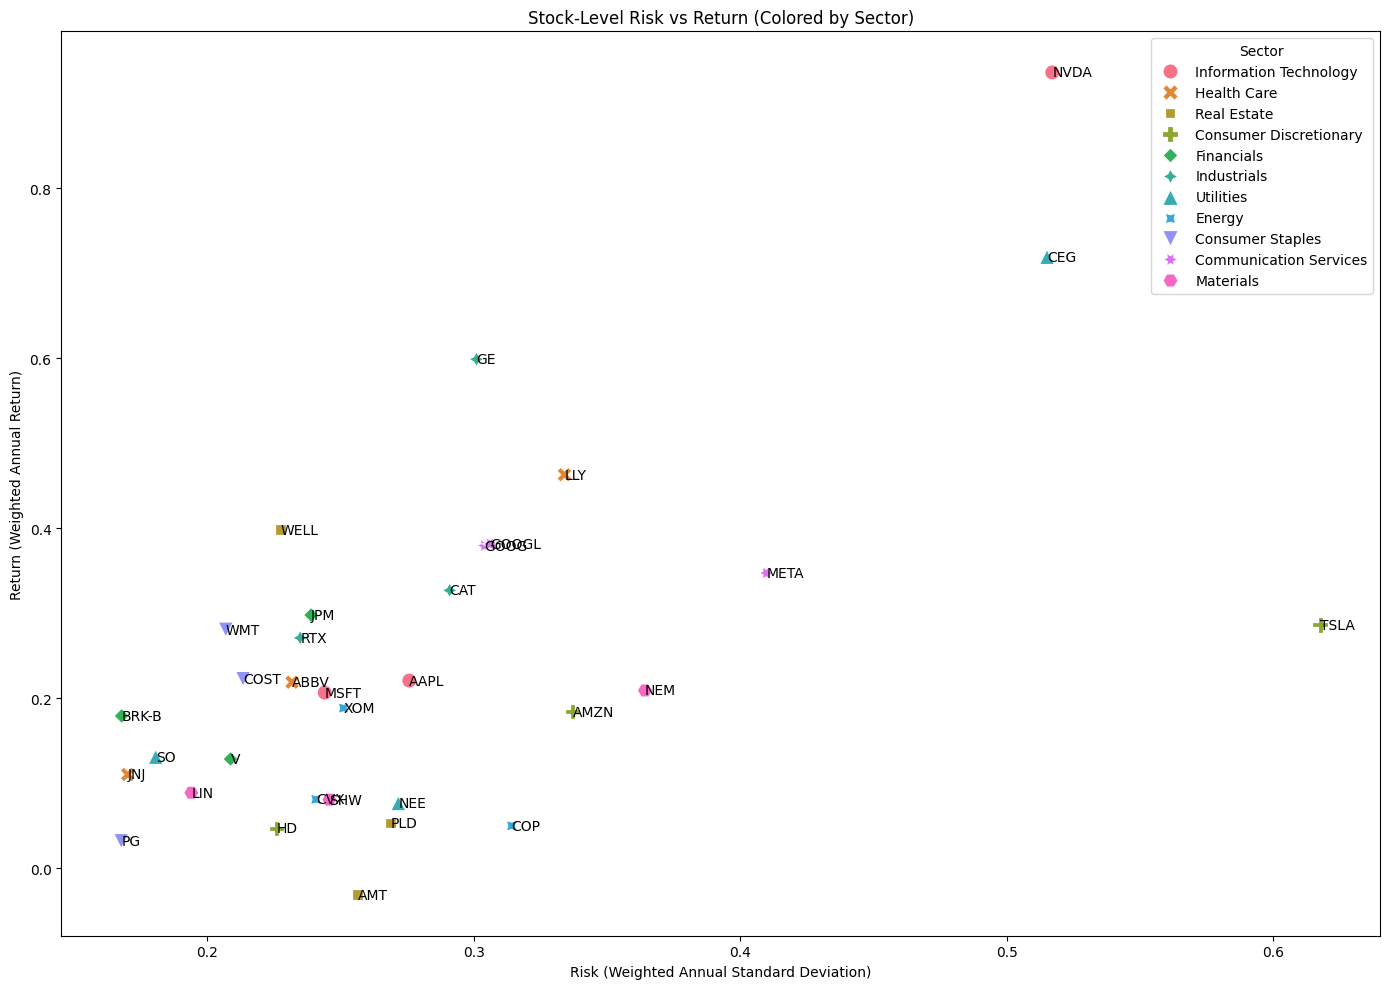

In [43]:
# Risk-Return Map By Stock
import seaborn as sns
import matplotlib.pyplot as plt

# Attach sector for coloring
df = weighted_summary2.merge(
    sp500_subset2[["Symbol", "Sector"]].drop_duplicates(),
    on="Symbol",
    how="left"
)

plt.figure(figsize=(14, 10))  # Larger figure size

sns.scatterplot(
    data=df,
    x="W_Annual_SD",
    y="W_Annual_Return",
    hue="Sector",
    style="Sector",
    s=120  # Larger marker size
 )

# Label each point with stock symbol
for _, row in df.iterrows():
    plt.text(
        row["W_Annual_SD"],  # Use correct x axis
        row["W_Annual_Return"],
        row["Symbol"],
        fontsize=10,
        ha='left',
        va='center'
    )

plt.xlabel("Risk (Weighted Annual Standard Deviation)")
plt.ylabel("Return (Weighted Annual Return)")
plt.title("Stock-Level Risk vs Return (Colored by Sector)")
plt.tight_layout()
plt.show()

In [44]:
# ============================================================
# EXPORT weighted_summary2 for optimization in VS Code
# ============================================================

mu_annual = weighted_summary2["W_Annual_Return"].values
sigma_annual = weighted_summary2["W_Annual_SD"].values
tickers = weighted_summary2["Symbol"].tolist()

np.save("mu_annual.npy", mu_annual)
np.save("sigma_annual.npy", sigma_annual)
pd.Series(tickers).to_csv("tickers.csv", index=False)

print("Exported: mu_annual.npy, sigma_annual.npy, tickers.csv")


Exported: mu_annual.npy, sigma_annual.npy, tickers.csv


In [45]:
print("Min weighted annual SD:", weighted_summary2["W_Annual_SD"].min())
print("Max weighted annual SD:", weighted_summary2["W_Annual_SD"].max())
print("Median weighted annual SD:", weighted_summary2["W_Annual_SD"].median())

Min weighted annual SD: 0.1677991128903937
Max weighted annual SD: 0.6175028196589601
Median weighted annual SD: 0.2511521800829071


In [46]:
import numpy as np
import pandas as pd

# sp500_subset2 has columns: Date, Symbol, LogReturn, ...
# make sure Date is datetime
sp500_subset["Date"] = pd.to_datetime(sp500_subset2["Date"])

# pivot to wide: rows = dates, columns = symbols, values = daily log returns
returns_wide = sp500_subset2.pivot(
    index="Date",
    columns="Symbol",
    values="LogReturn"
).sort_index()

# Drop days where everything is NaN (holidays where only some tickers missing is okay)
returns_wide = returns_wide.dropna(how="all")

# ---------- 1. Expected returns (mu) ----------
# daily mean log return per asset
mu_daily_log = returns_wide.mean(axis=0)          # shape (n,)

# annualize log returns
mu_annual_log = mu_daily_log * 252

# convert log return → arithmetic annual return
mu_annual = np.exp(mu_annual_log) - 1            # shape (n,)

# ---------- 2. Covariance matrix (Sigma) ----------
# sample covariance of daily log returns
cov_daily = returns_wide.cov()                   # shape (n, n)

# annualize cov
cov_annual = cov_daily * 252

# keep a consistent ticker order
tickers = returns_wide.columns.tolist()

# optionally save to disk (like your earlier code)
np.save("mu_annual2.npy", mu_annual.values)
np.save("cov_annual2.npy", cov_annual.values)
pd.Series(tickers).to_csv("tickers2.csv", index=False)


In [48]:
cov_annual

Symbol,AAPL,ABBV,AMT,AMZN,BRK-B,CAT,CEG,COP,COST,CVX,...,PG,PLD,RTX,SHW,SO,TSLA,V,WELL,WMT,XOM
Symbol,,,,,,,,,,,,,,,,,,,,,
AAPL,0.078362,0.009999,0.019367,0.055052,0.021212,0.024109,0.034702,0.019520,0.029687,0.016509,...,0.011981,0.034456,0.016270,0.027070,0.009541,0.084055,0.030668,0.017382,0.016726,0.014420
ABBV,0.009999,0.051005,0.014065,0.005078,0.012961,0.012243,0.003165,0.015981,0.009576,0.012481,...,0.013410,0.016409,0.012177,0.012266,0.012685,0.001974,0.013774,0.011930,0.009680,0.013206
AMT,0.019367,0.014065,0.067288,0.016610,0.013577,0.008091,0.009071,0.003691,0.016183,0.005156,...,0.016609,0.038749,0.011782,0.026266,0.024859,0.018771,0.017841,0.026565,0.010875,0.004261
AMZN,0.055052,0.005078,0.016610,0.123295,0.020793,0.029432,0.053441,0.019875,0.034153,0.015996,...,0.005556,0.037588,0.016934,0.029934,0.004071,0.094840,0.032171,0.016296,0.018118,0.011782
BRK-B,0.021212,0.012961,0.013577,0.020793,0.029812,0.024294,0.018279,0.024401,0.014913,0.020034,...,0.011118,0.020472,0.019521,0.017800,0.012591,0.025884,0.021446,0.016659,0.011927,0.019973
CAT,0.024109,0.012243,0.008091,0.029432,0.024294,0.084391,0.046314,0.047195,0.013004,0.037536,...,0.003073,0.027003,0.024584,0.022758,0.005748,0.046506,0.022522,0.018054,0.009453,0.037196
CEG,0.034702,0.003165,0.009071,0.053441,0.018279,0.046314,0.237361,0.041472,0.031026,0.028955,...,0.003634,0.034577,0.023298,0.023545,0.010793,0.083299,0.026148,0.018267,0.019115,0.023554
COP,0.019520,0.015981,0.003691,0.019875,0.024401,0.047195,0.041472,0.114980,0.007035,0.072260,...,0.002624,0.017615,0.033318,0.004459,0.008480,0.028800,0.019923,0.014021,0.008786,0.078512
COST,0.029687,0.009576,0.016183,0.034153,0.014913,0.013004,0.031026,0.007035,0.050925,0.007761,...,0.014968,0.024069,0.012231,0.022648,0.010066,0.047371,0.020086,0.014556,0.026274,0.006129


/var/folders/sx/rlv33lyd2zs6vjp3khdjp3dc0000gn/T/ipykernel_71211/86340171.py:17: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  sector_corr = corr_annual_sector.groupby(corr_annual_sector.index).mean().groupby(corr_annual_sector.columns, axis=1).mean()


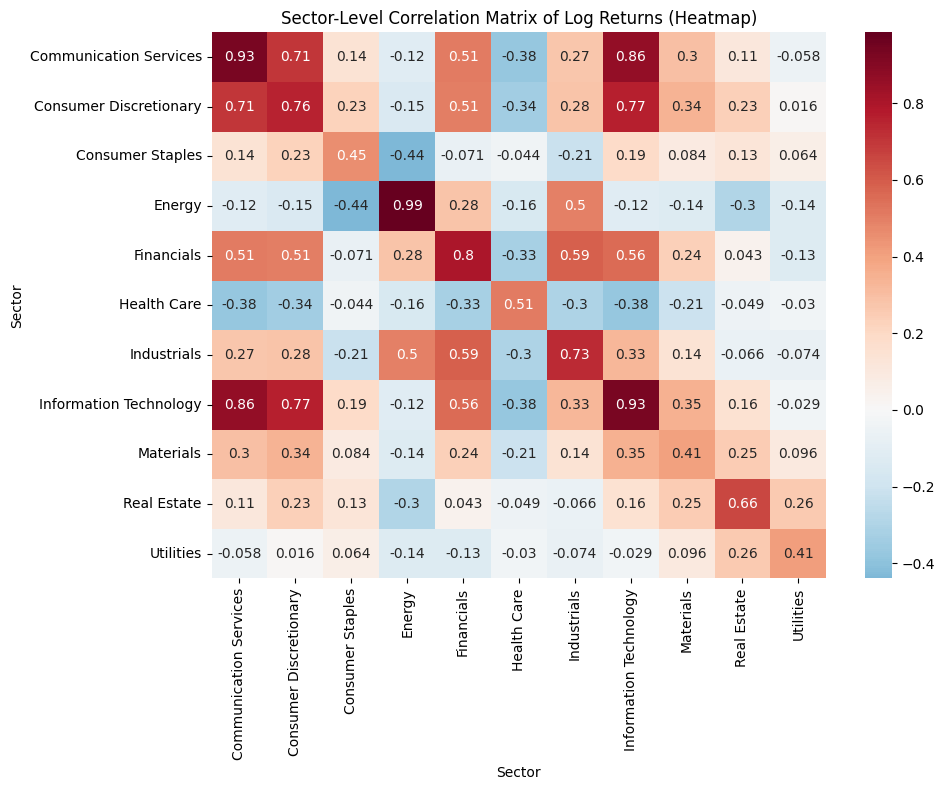

In [56]:
# Sector-level correlation heatmap (negative=red, positive=dark blue)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Map symbols to sectors
symbol_sector = sp500_subset2[["Symbol", "Sector"]].drop_duplicates().set_index("Symbol")
sector_map = symbol_sector["Sector"].to_dict()

# Create sector-level correlation matrix
corr_annual_sector = corr_annual.copy()
corr_annual_sector.index = corr_annual_sector.index.map(sector_map)
corr_annual_sector.columns = corr_annual_sector.columns.map(sector_map)

# Aggregate by sector: mean correlation between sectors
sector_corr = corr_annual_sector.groupby(corr_annual_sector.index).mean().groupby(corr_annual_sector.columns, axis=1).mean()

plt.figure(figsize=(10, 8))
sns.heatmap(sector_corr, annot=True, cmap="RdBu_r", center=0)
plt.title("Sector-Level Correlation Matrix of Log Returns (Heatmap)")
plt.xlabel("Sector")
plt.ylabel("Sector")
plt.tight_layout()
plt.show()